# Analisis dan Prediksi Jumlah Kasus Demam Berdarah Dengue (DBD) Menggunakan Algoritma Random Forest Regression

## 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

## 2. Load Dataset

In [3]:
df = pd.read_excel("dataset_dengue_gabungan.xlsx")
print(df.head())
print(df.info())

  city  year  weekofyear week_start_date   ndvi_ne   ndvi_nw   ndvi_se  \
0   sj  1990          18      1990-04-30  0.122600  0.103725  0.198483   
1   sj  1990          19      1990-05-07  0.169900  0.142175  0.162357   
2   sj  1990          20      1990-05-14  0.032250  0.172967  0.157200   
3   sj  1990          21      1990-05-21  0.128633  0.245067  0.227557   
4   sj  1990          22      1990-05-28  0.196200  0.262200  0.251200   

    ndvi_sw  precipitation_amt_mm  reanalysis_air_temp_k  ...  \
0  0.177617                 12.42             297.572857  ...   
1  0.155486                 22.82             298.211429  ...   
2  0.170843                 34.54             298.781429  ...   
3  0.235886                 15.36             298.987143  ...   
4  0.247340                  7.52             299.518571  ...   

   reanalysis_relative_humidity_percent  reanalysis_sat_precip_amt_mm  \
0                             73.365714                         12.42   
1                 

In [4]:
print("Ukuran dataset:", df.shape)

Ukuran dataset: (1872, 25)


## 3. Preprocessing

### 3.1 Cek Missing Value & Duplikat

In [5]:
print("Missing values:")
print(df.isnull().sum())
print("\nJumlah duplikat:", df.duplicated().sum())

Missing values:
city                                       0
year                                       0
weekofyear                                 0
week_start_date                            0
ndvi_ne                                  237
ndvi_nw                                   63
ndvi_se                                   23
ndvi_sw                                   23
precipitation_amt_mm                      15
reanalysis_air_temp_k                     12
reanalysis_avg_temp_k                     12
reanalysis_dew_point_temp_k               12
reanalysis_max_air_temp_k                 12
reanalysis_min_air_temp_k                 12
reanalysis_precip_amt_kg_per_m2           12
reanalysis_relative_humidity_percent      12
reanalysis_sat_precip_amt_mm              15
reanalysis_specific_humidity_g_per_kg     12
reanalysis_tdtr_k                         12
station_avg_temp_c                        55
station_diur_temp_rng_c                   55
station_max_temp_c                     

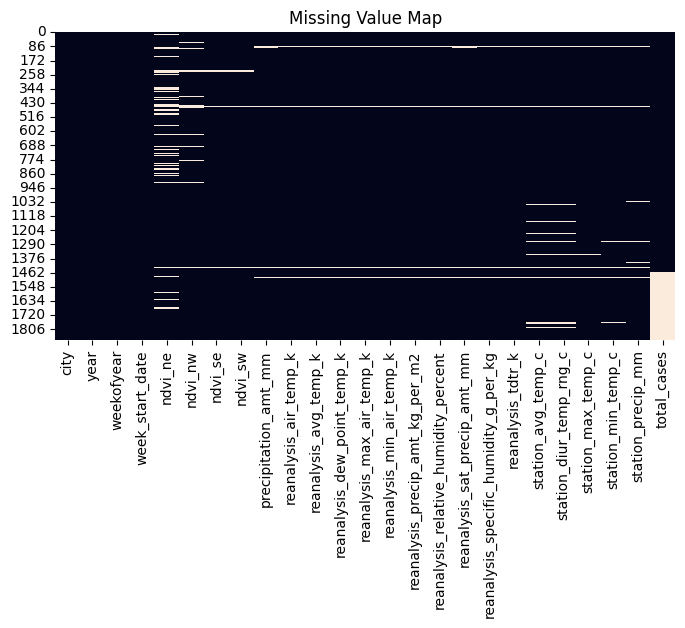

In [6]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Map")
plt.show()

### 3.2 Imputasi Missing Value

In [7]:
df['station_precip_mm'] = df['station_precip_mm'].fillna(df['station_precip_mm'].median())

### 3.3 Feature Engineering (Lag & Rolling Mean)

In [8]:
df = df.sort_values(['city', 'year']).reset_index(drop=True)

# Lag 1 tahun per kabupaten
df['total_cases_Lag1'] = df.groupby('city')['total_cases'].shift(1)

# Rata-rata rolling 2 tahun sebelumnya
df['total_cases_RollMean2'] = df.groupby('city')['total_cases'].transform(
    lambda x: x.shift(1).rolling(2, min_periods=1).mean()
)

df = df.dropna().reset_index(drop=True)
print("Shape setelah dropna:", df.shape)

Shape setelah dropna: (1207, 27)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Statistik Deskriptif

In [9]:
df.describe()

,year,weekofyear,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,...,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,total_cases_Lag1,total_cases_RollMean2
count,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,...,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000,1207.000000
mean,2001.353770,26.477216,0.140430,0.135339,0.205744,0.205908,47.554979,298.677530,299.250834,295.298639,...,16.805843,5.183312,27.236097,8.278387,32.591632,22.068103,40.826098,21.119304,20.981773,20.891052
std,5.346062,14.905983,0.140152,0.121079,0.074826,0.085740,43.147669,1.366113,1.267241,1.505078,...,1.522962,3.627138,1.266184,2.195777,1.957832,1.555006,48.841014,30.778091,30.376843,29.675888
min,1990.000000,1.000000,-0.406250,-0.456100,-0.015533,-0.063457,0.000000,294.635714,294.892857,289.642857,...,11.715714,1.357143,21.400000,4.528571,26.700000,14.700000,0.000000,0.000000,0.000000,0.000000
25%,1998.000000,14.000000,0.043850,0.051800,0.155829,0.144950,12.550000,297.640000,298.296429,294.215000,...,15.649286,2.357143,26.446429,6.600000,31.600000,21.100000,9.850000,4.000000,4.000000,4.500000
50%,2002.000000,27.000000,0.127317,0.127150,0.196729,0.192314,41.410000,298.627143,299.335714,295.674286,...,17.145714,3.014286,27.466667,7.500000,32.800000,22.000000,24.300000,11.000000,11.000000,11.000000
75%,2006.000000,39.000000,0.247086,0.223244,0.252550,0.254679,71.765000,299.792143,300.228571,296.500714,...,18.011429,8.150000,28.171429,10.066667,33.900000,23.300000,55.800000,26.000000,26.000000,25.500000
max,2010.000000,52.000000,0.508357,0.454429,0.538314,0.546017,390.600000,302.200000,302.928571,298.450000,...,20.461429,16.028571,30.800000,15.800000,42.200000,25.600000,543.300000,329.000000,329.000000,296.000000


### Distribusi DBD

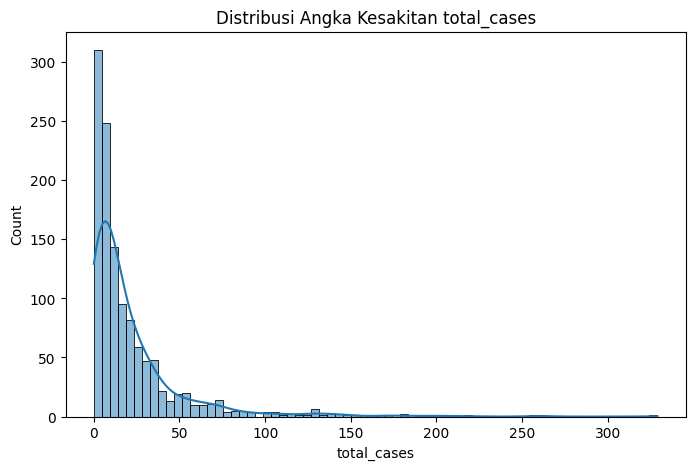

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['total_cases'],
    kde=True
)

plt.title(
    "Distribusi Angka Kesakitan total_cases"
)

plt.show()

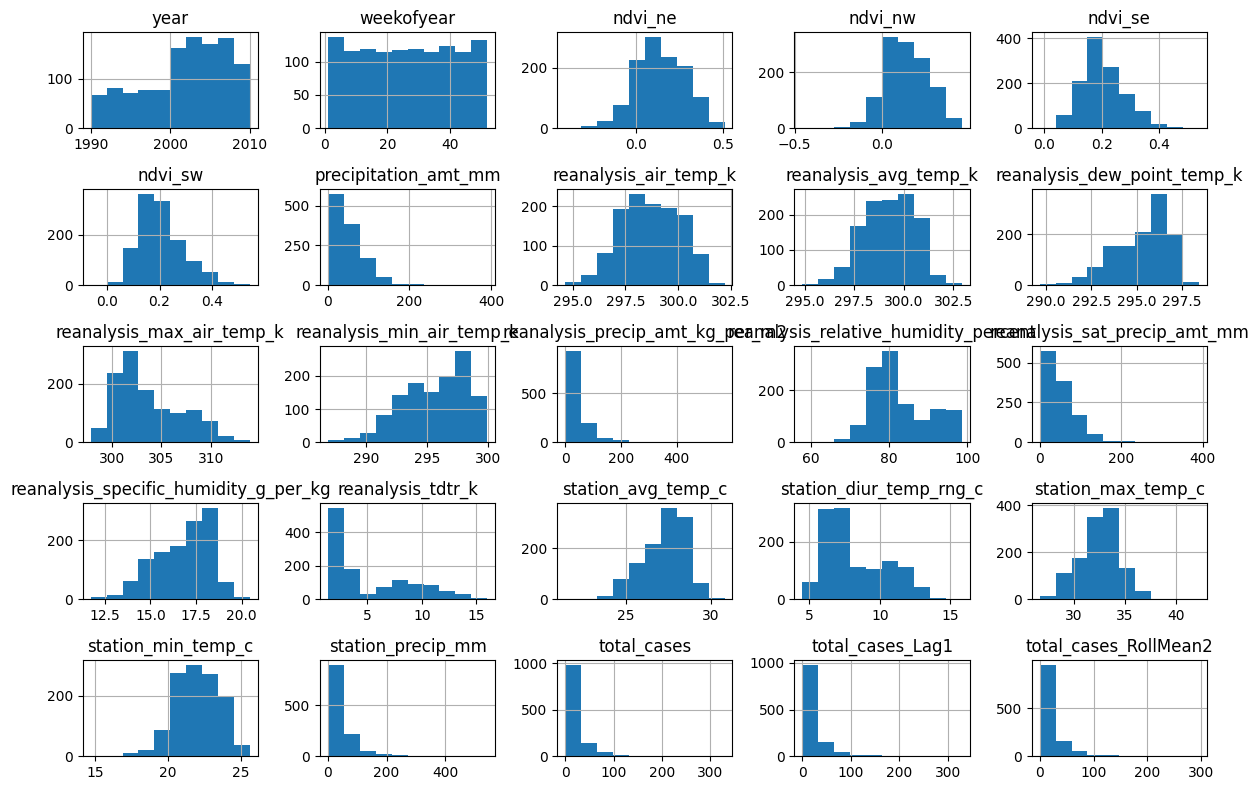

In [11]:
df.hist(
    figsize=(12,8)
)

plt.tight_layout()
plt.show()

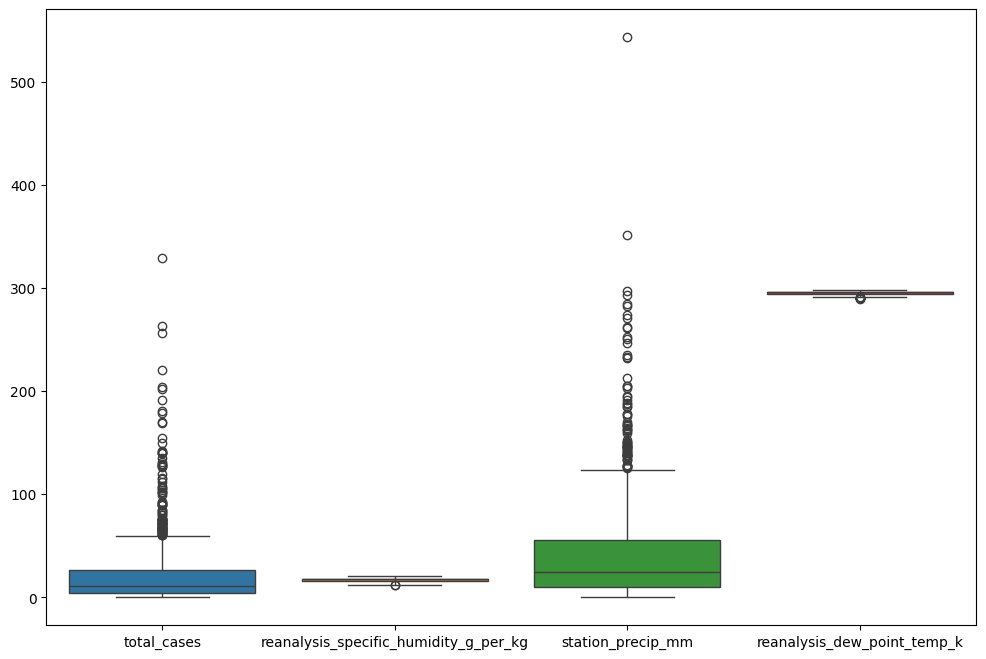

In [12]:
plt.figure(figsize=(12,8))

sns.boxplot(
    data=df[
        [
            'total_cases',
            'reanalysis_specific_humidity_g_per_kg',
            'station_precip_mm',
            'reanalysis_dew_point_temp_k'
        ]
    ]
)

plt.show()

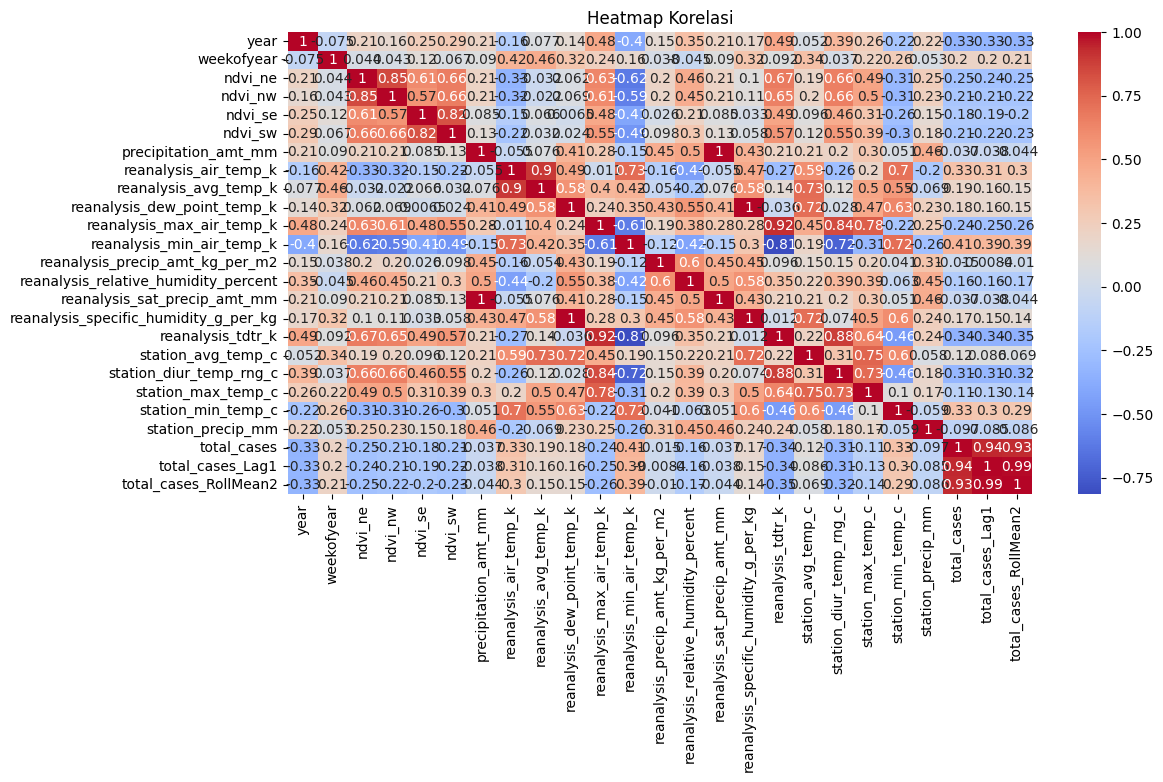

In [13]:
corr = df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(12,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Heatmap Korelasi"
)

plt.show()

In [14]:
fitur = [

    'station_precip_mm',

    'reanalysis_specific_humidity_g_per_kg',

    'reanalysis_dew_point_temp_k',

    'total_cases_Lag1',

    'total_cases_RollMean2'
]

for kolom in fitur:

    corr, p = pearsonr(
        df[kolom],
        df['total_cases']
    )

    print(
        f"{kolom} → "
        f"Korelasi={corr:.4f}, "
        f"P-value={p:.4f}"
    )

station_precip_mm → Korelasi=-0.0974, P-value=0.0007
reanalysis_specific_humidity_g_per_kg → Korelasi=0.1663, P-value=0.0000
reanalysis_dew_point_temp_k → Korelasi=0.1811, P-value=0.0000
total_cases_Lag1 → Korelasi=0.9427, P-value=0.0000
total_cases_RollMean2 → Korelasi=0.9319, P-value=0.0000


### 4.4 Distribusi Variabel

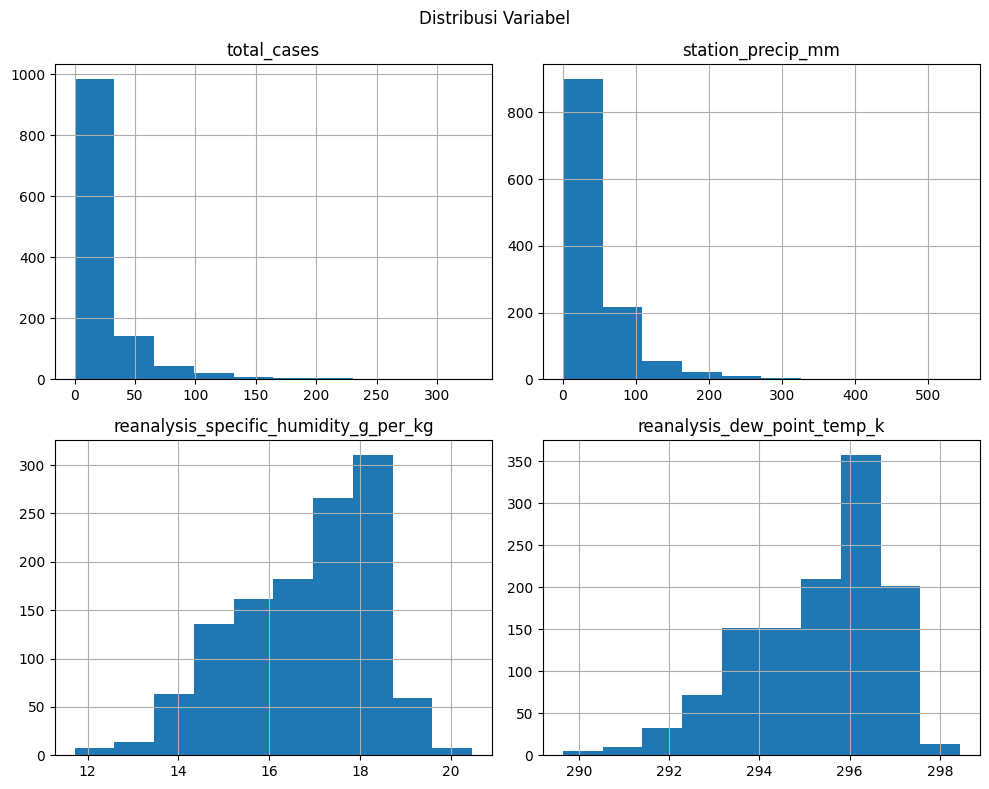

In [15]:
df[['total_cases', 'station_precip_mm',
    'reanalysis_specific_humidity_g_per_kg', 'reanalysis_dew_point_temp_k']].hist(figsize=(10, 8))
plt.suptitle("Distribusi Variabel")
plt.tight_layout()
plt.show()

### 4.5 Boxplot Outlier

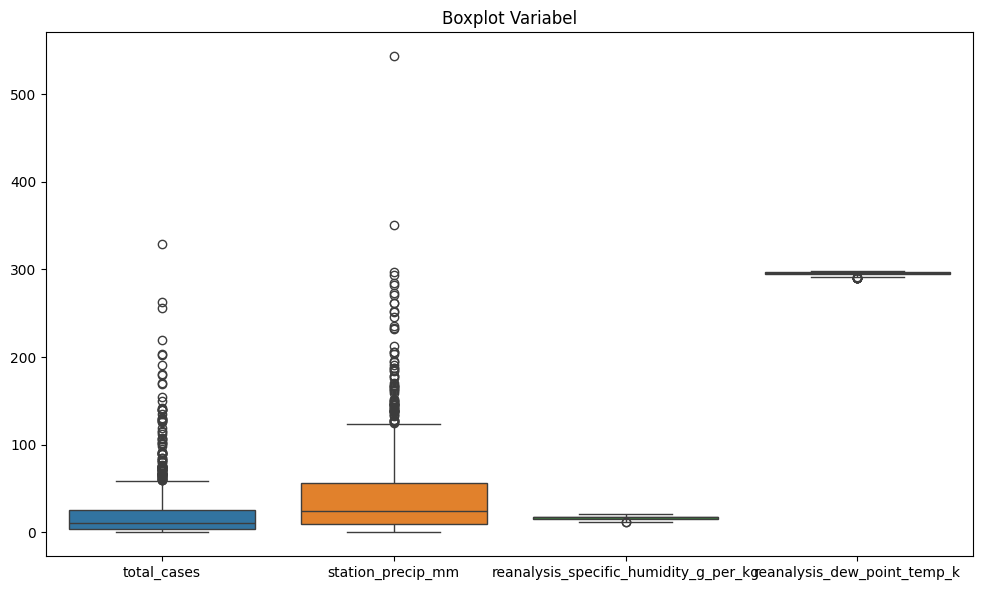

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['total_cases', 'station_precip_mm',
                      'reanalysis_specific_humidity_g_per_kg', 'reanalysis_dew_point_temp_k']])
plt.title("Boxplot Variabel")
plt.tight_layout()
plt.show()

### 4.6 Tren Rata-rata DBD per Tahun

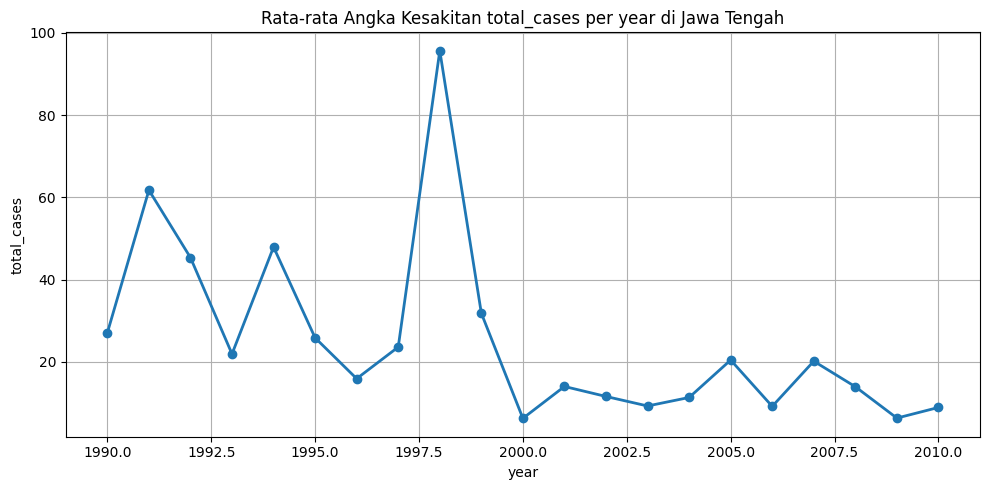

In [17]:
plt.figure(figsize=(10, 5))
tren = df.groupby('year')['total_cases'].mean()
plt.plot(tren.index, tren.values, marker='o', linewidth=2)
plt.title("Rata-rata Angka Kesakitan total_cases per year di Jawa Tengah")
plt.xlabel("year")
plt.ylabel("total_cases")
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Split Data (Time-Based)



In [18]:
X = df[
[
'reanalysis_specific_humidity_g_per_kg',
'station_precip_mm',
'reanalysis_dew_point_temp_k',
'total_cases_Lag1',
'total_cases_RollMean2'
]
]

y = df['total_cases']

In [19]:
from sklearn.model_selection import train_test_split

data_train = df[df['total_cases'].notna()].copy()

X = data_train[fitur]
y = data_train['total_cases']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

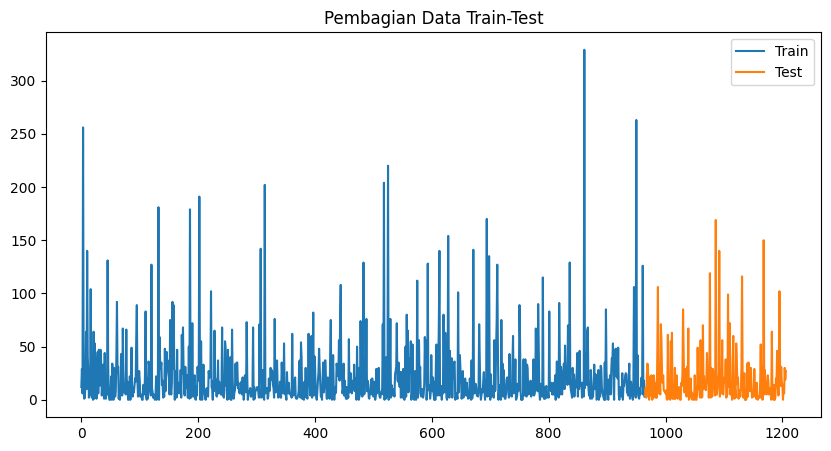

In [33]:
plt.figure(figsize=(10,5))
plt.plot(y_train.reset_index(drop=True), label='Train')
plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test.values, label='Test')
plt.title('Pembagian Data Train-Test')
plt.legend()
plt.show()

# 6. Pembangunan Model Random Forest Regression

In [20]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(965, 5)
(242, 5)
(965,)
(242,)


In [22]:
X_train.dtypes

station_precip_mm                        float64
reanalysis_specific_humidity_g_per_kg    float64
reanalysis_dew_point_temp_k              float64
total_cases_Lag1                         float64
total_cases_RollMean2                    float64
dtype: object

In [23]:
len(rf.estimators_)

100

## 7. Hyperparameter Tuning

In [24]:
param_grid = {

'n_estimators':
[100,200,300],

'max_depth':
[5,10,15,None],

'min_samples_split':
[2,5,10],

'min_samples_leaf':
[1,2,4]
}

In [25]:
grid_search = GridSearchCV(

    estimator=
    RandomForestRegressor(
        random_state=42
    ),

    param_grid=
    param_grid,

    cv=5,

    scoring='r2',

    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

## 8. Pelatihan Model Terbaik & Prediksi

In [26]:
grid_search.best_params_

best_rf = (
    grid_search.best_estimator_
)

## 9. Evaluasi Model

### 9.1 Metrik Evaluasi

In [30]:
y_pred = (
    best_rf.predict(X_test)
)
mae = mean_absolute_error(
    y_test,
    y_pred
)
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)
r2 = r2_score(
    y_test,
    y_pred
)
print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 5.60828661782206
RMSE = 10.05923538921549
R² = 0.8493361631753863


### 9.2 Tabel Hasil Prediksi

In [31]:
hasil_prediksi = pd.DataFrame({
    'Aktual': y_test.values,
    'Prediksi': y_pred
})

hasil_prediksi['Error'] = (
    hasil_prediksi['Aktual']
    - hasil_prediksi['Prediksi']
)

hasil_prediksi.head(20)

,Aktual,Prediksi,Error
0,4.0,7.674204,-3.674204
1,11.0,6.840511,4.159489
2,2.0,3.763446,-1.763446
3,22.0,12.031842,9.968158
4,34.0,29.506484,4.493516
5,30.0,31.312526,-1.312526
6,4.0,7.082296,-3.082296
7,0.0,1.288774,-1.288774
8,12.0,12.788272,-0.788272
9,22.0,12.900295,9.099705


In [32]:
hasil_prediksi.to_excel(
    "hasil_prediksi_dbd.xlsx",
    index=False
)

### 9.3 Plot Aktual vs Prediksi (Line)

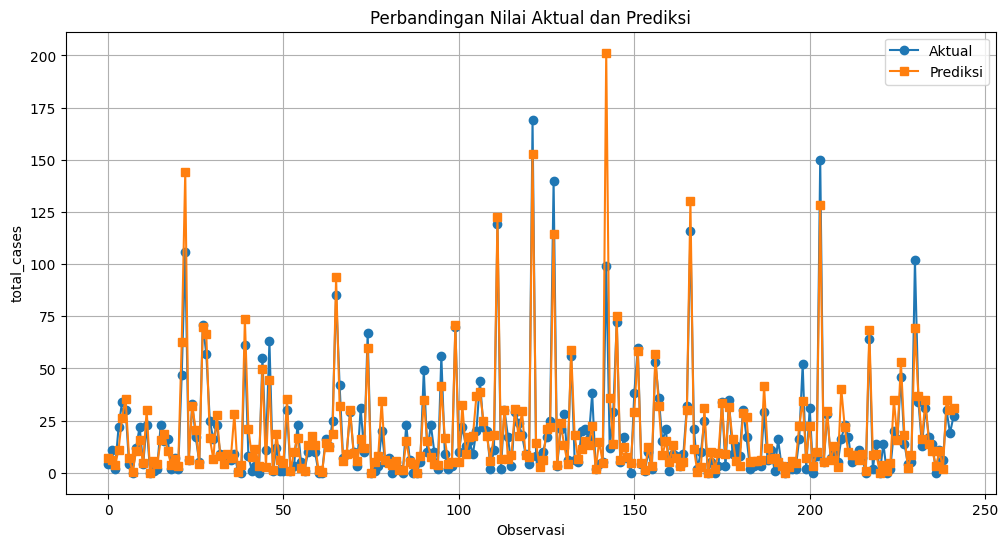

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Aktual',
    marker='o'
)

plt.plot(
    y_pred,
    label='Prediksi',
    marker='s'
)

plt.title(
    'Perbandingan Nilai Aktual dan Prediksi'
)

plt.xlabel('Observasi')

plt.ylabel('total_cases')

plt.legend()

plt.grid(True)

plt.show()

### 9.4 Scatter Plot Aktual vs Prediksi

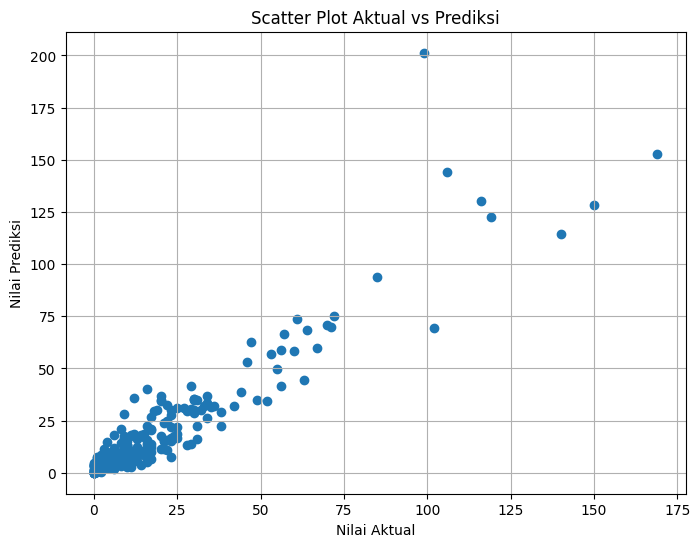

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel('Nilai Aktual')

plt.ylabel('Nilai Prediksi')

plt.title(
    'Scatter Plot Aktual vs Prediksi'
)

plt.grid(True)

plt.show()

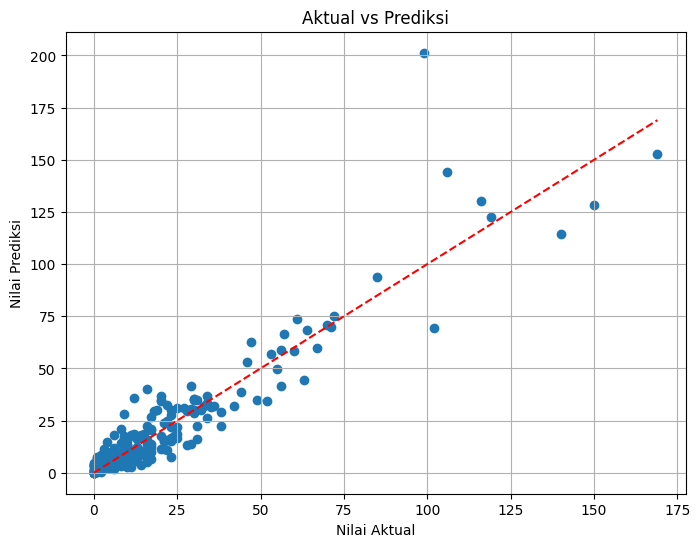

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Nilai Aktual')

plt.ylabel('Nilai Prediksi')

plt.title(
    'Aktual vs Prediksi'
)

plt.grid(True)

plt.show()

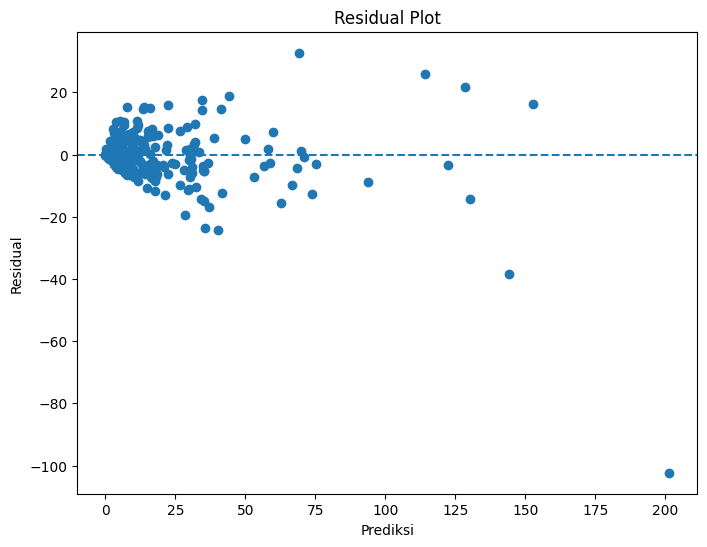

In [ ]:
residual = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residual
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Prediksi')

plt.ylabel('Residual')

plt.title(
    'Residual Plot'
)

plt.show()

## 10. Feature Importance

In [ ]:
importance = pd.DataFrame({

'Feature':
X.columns,

'Importance':
best_rf.feature_importances_

})

In [ ]:
importance = (
    importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

importance

,Feature,Importance
3,total_cases_Lag1,0.670640
4,total_cases_RollMean2,0.297293
0,station_precip_mm,0.020444
2,reanalysis_dew_point_temp_k,0.005957
1,reanalysis_specific_humidity_g_per_kg,0.005666


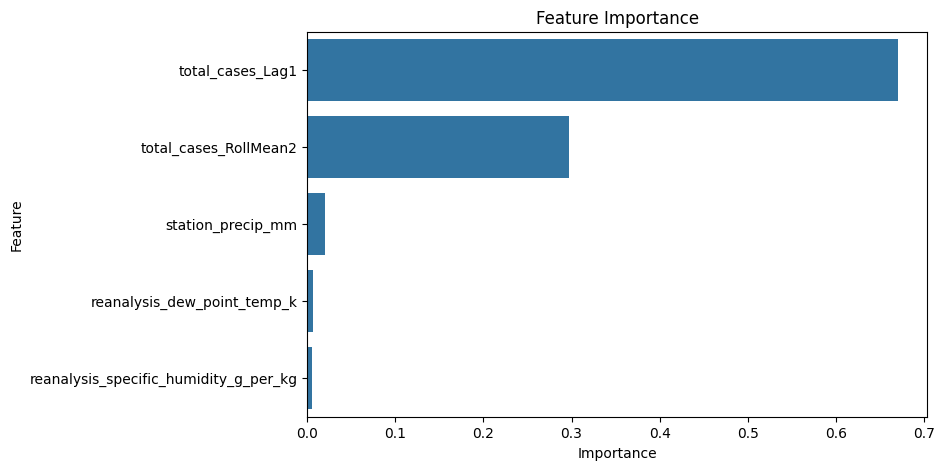

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x='Importance',

    y='Feature'
)

plt.title(
    "Feature Importance"
)

plt.show()

## 11. Forecast Tahun Berikutnya

In [ ]:
data_terakhir = X.iloc[[-1]]
prediksi_next = best_rf.predict(data_terakhir)
print('Prediksi kasus DBD periode berikutnya =', round(prediksi_next[0]))

Prediksi kasus DBD periode berikutnya = 3
